
# Phân tích dữ liệu game + khảo sát

Notebook này đọc:

- `data.json`: log chơi game, gồm `players`, `sessions`, `final_scores`, `traces`
- `Dữ liệu đánh giá.xlsx`: Form1, Form2 và tab `Phổ điểm`

Mục tiêu:

1. Tách log game thành bảng session / trace
2. Thống kê hiệu quả game và hành vi trong game
3. Tính score từ khảo sát
4. Ghép game với khảo sát theo email
5. Hỗ trợ chọn mẫu control matched từ nhóm chưa chơi


### 1. Load Data & lọc Data

In [13]:

from pathlib import Path
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import openpyxl

from IPython.display import display

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)
plt.rcParams["figure.figsize"] = (10, 4)

BASE_DIR = Path.cwd()
GAME_PATH = BASE_DIR / "data.json"
SURVEY_PATH = BASE_DIR / "Dữ liệu đánh giá.xlsx"

GAME_PATH, SURVEY_PATH


(WindowsPath('e:/COLLEGE/HK252/DATN/Analytics/data.json'),
 WindowsPath('e:/COLLEGE/HK252/DATN/Analytics/Dữ liệu đánh giá.xlsx'))

In [14]:
def load_game_json(path: Path):
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)

def flatten_game(game: dict):
    players = pd.DataFrame.from_dict(game.get("players", {}), orient="index").reset_index(drop=False)
    players = players.rename(columns={"index": "player_id"})
    if "email" in players.columns:
        players["email_norm"] = players["email"].astype(str).str.strip().str.lower()

    session_rows = []
    trace_rows = []

    for session_id, s in game.get("sessions", {}).items():
        fs = s.get("final_scores") or {}
        session_row = {
            "session_id": session_id,
            "player_id": s.get("player_id"),
            "is_completed": bool(s.get("is_completed", False)),
            "start_time": s.get("start_time"),
            "end_time": s.get("end_time"),
            "total_playtime_seconds": s.get("total_playtime_seconds"),
            "n_traces": len(s.get("traces") or []),
        }
        session_row.update(fs)
        session_rows.append(session_row)

        for idx, t in enumerate(s.get("traces") or []):
            trace_row = {
                "session_id": session_id,
                "player_id": s.get("player_id"),
                "trace_index": idx,
                "choice_id": t.get("choice_id"),
                "milestone_id": t.get("milestone_id"),
                "object_name": t.get("object_name"),
                "route_id": t.get("route_id"),
                "trace_id": t.get("trace_id"),
                "timestamp": t.get("timestamp"),
            }
            trace_row.update(t.get("score_state") or {})
            trace_rows.append(trace_row)

    sessions = pd.DataFrame(session_rows)
    traces = pd.DataFrame(trace_rows)

    score_cols = [c for c in sessions.columns if c.startswith("SCORE_")]
    if score_cols:
        sessions["mean_final_score"] = sessions[score_cols].mean(axis=1)

    if not traces.empty:
        trace_score_cols = [c for c in traces.columns if c.startswith("SCORE_")]
        traces["mean_trace_score"] = traces[trace_score_cols].mean(axis=1)

    return players, sessions, traces

game = load_game_json(GAME_PATH)
players_df, sessions_df, traces_df = flatten_game(game)

# Loại bỏ 2 account test
test_emails = ["test@gmail.com", "test2@gmail.com"]
players_df = players_df[~players_df["email_norm"].isin(test_emails)]

# Lọc session theo player hợp lệ
valid_player_ids = players_df["player_id"].tolist()
sessions_df = sessions_df[sessions_df["player_id"].isin(valid_player_ids)]
#bỏ session có time = 0
sessions_df = sessions_df[sessions_df["total_playtime_seconds"] > 30]

# Lọc trace theo session hợp lệ
valid_session_ids = sessions_df["session_id"].tolist()
traces_df = traces_df[traces_df["session_id"].isin(valid_session_ids)]

print("players:", len(players_df))
print("sessions:", len(sessions_df))
print("traces:", len(traces_df))
display(players_df.head())
display(sessions_df.head())
display(traces_df.head())

players: 11
sessions: 14
traces: 190


,player_id,created_at,email,userid,email_norm
0,1gJPPFrwADbPzDMNxwIhKHuCPWv1,1780229061876,player12@gmail.com,1gJPPFrwADbPzDMNxwIhKHuCPWv1,player12@gmail.com
1,40f1uksF5kYFvJ5WxoYBzlBCfBE2,1780224831276,player10@gmail.com,40f1uksF5kYFvJ5WxoYBzlBCfBE2,player10@gmail.com
3,EOOUznHcdYM3B5Eu7H7303gt3Nl1,1780201574930,player5@gmail.com,EOOUznHcdYM3B5Eu7H7303gt3Nl1,player5@gmail.com
4,Phcnngo3Fddhr78h6wLbEE8qeW22,1780200089650,player3@gmail.com,Phcnngo3Fddhr78h6wLbEE8qeW22,player3@gmail.com
5,VYZqyGu79USyXvpxpxWmk0lxnAE3,1780225302996,player11@gmail.com,VYZqyGu79USyXvpxpxWmk0lxnAE3,player11@gmail.com


,session_id,player_id,is_completed,start_time,end_time,total_playtime_seconds,n_traces,SCORE_COMMUNITY_WARNING,SCORE_HELP_SEEKING,SCORE_INFORMATION_VERIFICATION,SCORE_PRESSURE_RESISTANCE,SCORE_RISK_RECOGNITION,mean_final_score
3,1fb026953dc846bc97dd4e7d57f23e00,vYmu30ZTOHbjiC4mPuaw73q6pZf1,True,1.780224e+12,1.780226e+12,1535.671,17,66,80,85,74,76,76.2
10,4943e96963484c518a7a89e411957f59,VYZqyGu79USyXvpxpxWmk0lxnAE3,True,1.780225e+12,1.780227e+12,1605.298,17,58,85,87,74,76,76.0
11,49c815d91834424d88c57e1bd5ace9e0,40f1uksF5kYFvJ5WxoYBzlBCfBE2,True,1.780225e+12,1.780226e+12,1248.226,14,66,75,68,54,62,65.0
16,66c3226e840e461a902dffc6c8ac249c,1gJPPFrwADbPzDMNxwIhKHuCPWv1,True,1.780229e+12,1.780230e+12,496.455,15,66,65,2,30,26,37.8
17,6d8d8ee5a4d64040866aab590a3ddfeb,vroJdrAh69TH16ZpHxlCqeIplRw1,False,1.780228e+12,1.780229e+12,532.545,0,50,50,50,50,50,50.0


,session_id,player_id,trace_index,choice_id,milestone_id,object_name,route_id,trace_id,timestamp,SCORE_COMMUNITY_WARNING,SCORE_HELP_SEEKING,SCORE_INFORMATION_VERIFICATION,SCORE_PRESSURE_RESISTANCE,SCORE_RISK_RECOGNITION,mean_trace_score
8,1fb026953dc846bc97dd4e7d57f23e00,vYmu30ZTOHbjiC4mPuaw73q6pZf1,0,1,0,m0_email_checkin,CH1_M0_R0_BB_1,TRACE_READ_RELEVANT_INFO,1780224402748,50,50,50,50,50,50.0
9,1fb026953dc846bc97dd4e7d57f23e00,vYmu30ZTOHbjiC4mPuaw73q6pZf1,1,1,0,m0_guard,CH1_M0_R0_BB_3,TRACE_ASK_PERSON,1780224486665,50,50,52,50,50,50.4
10,1fb026953dc846bc97dd4e7d57f23e00,vYmu30ZTOHbjiC4mPuaw73q6pZf1,2,1,0,m0_linh_askgroup,CH1_M0_R0_BB_4,TRACE_ASK_PERSON,1780224637397,50,55,54,50,50,51.8
11,1fb026953dc846bc97dd4e7d57f23e00,vYmu30ZTOHbjiC4mPuaw73q6pZf1,3,2,0,m1_roommate_askdoc,CH1_M0_R0_BB_13,TRACE_ASK_PERSON,1780225166096,50,60,56,50,50,53.2
12,1fb026953dc846bc97dd4e7d57f23e00,vYmu30ZTOHbjiC4mPuaw73q6pZf1,4,1,1,m1_link_freedoc,CH1_M1_R2_BB_2,TRACE_OPEN_UNVERIFIED_LINK,1780225241443,50,65,58,50,50,54.6


### 2. Phân tích tổng quan và Mức độ tương tác (Engagement Metrics)

Đánh giá mức độ thu hút, tính hấp dẫn và độ dài kịch bản game thông qua thời gian chơi trung bình và tỷ lệ hoàn tất. Dùng số liệu này để chứng minh game có độ dài vừa phải, không gây nhàm chán, giữ chân được người chơi.

,Kết quả ghi nhận
Số người chơi hợp lệ,11.00
Tổng số session chơi,14.00
Số người chơi hoàn thành,11.00
Số session hoàn thành,12.00
Số session bỏ dở,2.00
Tỷ lệ session hoàn thành %,85.70
Thời gian chơi trung bình (phút),20.63
Tổng thời gian chơi (phút),288.79
Thời gian chơi trung bình hoàn thành (phút),23.05
Thời gian chơi trung bình bỏ dở (phút),6.08


SCORE_COMMUNITY_WARNING              SCORE_HELP_SEEKING              SCORE_INFORMATION_VERIFICATION              SCORE_PRESSURE_RESISTANCE  \
                                mean median count               mean median count                           mean median count                      mean   
is_completed                                                                                                                                              
False                          50.00   50.0     2              50.00   50.0     2                          51.00   51.0     2                     50.00   
True                           62.67   66.0    12              76.67   80.0    12                          56.08   66.5    12                     56.67   

                          SCORE_RISK_RECOGNITION              mean_final_score               
             median count                   mean median count             mean median count  
is_completed                                                                                 
False          50.0     2                  50.00   50.0     2            50.20   50.2     2  
True           60.0    12                  56.17   63.0    12            61.65   64.7    12

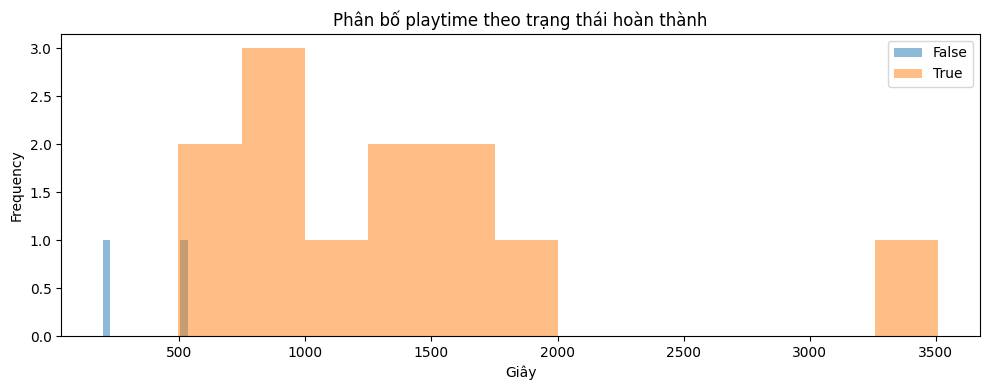

,player_id,session_count,email,total_playtime_minutes,SCORE_COMMUNITY_WARNING,SCORE_HELP_SEEKING,SCORE_INFORMATION_VERIFICATION,SCORE_PRESSURE_RESISTANCE,SCORE_RISK_RECOGNITION,mean_final_score
0,vroJdrAh69TH16ZpHxlCqeIplRw1,2,player8@gmail.com,40.582800,58.0,65.0,54.0,55.0,54.0,57.2
1,cx0jXpRTPFb30Gsm6QOvt3Hh6KJ3,2,player4@gmail.com,16.840633,50.0,57.5,26.0,33.0,25.0,38.3
2,Phcnngo3Fddhr78h6wLbEE8qeW22,2,player3@gmail.com,40.633817,66.0,75.0,54.0,54.0,59.0,61.6
3,EOOUznHcdYM3B5Eu7H7303gt3Nl1,1,player5@gmail.com,11.429300,66.0,70.0,58.0,68.0,60.0,64.4
4,40f1uksF5kYFvJ5WxoYBzlBCfBE2,1,player10@gmail.com,20.803767,66.0,75.0,68.0,54.0,62.0,65.0
5,1gJPPFrwADbPzDMNxwIhKHuCPWv1,1,player12@gmail.com,8.274250,66.0,65.0,2.0,30.0,26.0,37.8
6,VYZqyGu79USyXvpxpxWmk0lxnAE3,1,player11@gmail.com,26.754967,58.0,85.0,87.0,74.0,76.0,76.0
7,aUwWXivyj0VBPP4fmL3STw6ydC83,1,player7@gmail.com,58.500883,66.0,85.0,73.0,66.0,64.0,70.8
8,dhiHXvJmYgaNYeeE3QVoo77dMwf1,1,player6@gmail.com,22.850967,66.0,80.0,68.0,76.0,70.0,72.0
9,sjbR7vKNWOfZzrhOxDyyO257XKZ2,1,player13@gmail.com,16.527600,50.0,85.0,66.0,54.0,64.0,63.8


In [63]:
# 1. Mức độ tương tác (Engagement Metrics)
summary = {
    "Số người chơi hợp lệ": len(players_df),
    "Tổng số session chơi": len(sessions_df),
    "Số người chơi hoàn thành": int((sessions_df.groupby('player_id')['is_completed'].sum() > 0).sum()),
    "Số session hoàn thành": sessions_df["is_completed"].sum(),
    "Số session bỏ dở": sessions_df["is_completed"].count() - sessions_df["is_completed"].sum(),
    "Tỷ lệ session hoàn thành %": round(sessions_df["is_completed"].mean() * 100, 1),
    "Thời gian chơi trung bình (phút)": round(sessions_df["total_playtime_seconds"].mean() / 60, 2),
    "Tổng thời gian chơi (phút)": round(sessions_df["total_playtime_seconds"].sum() / 60, 2),
    "Thời gian chơi trung bình hoàn thành (phút)": round(sessions_df.loc[sessions_df["is_completed"], "total_playtime_seconds"].mean() / 60, 2),
    "Thời gian chơi trung bình bỏ dở (phút)": round(sessions_df.loc[~sessions_df["is_completed"], "total_playtime_seconds"].mean() / 60, 2),
}
display(pd.DataFrame(summary, index=["Kết quả ghi nhận"]).T)

# Hiển thị điểm số theo việc hoàn thành hay không
score_cols = [c for c in sessions_df.columns if c.startswith("SCORE_")]
display(
    sessions_df.groupby("is_completed")[score_cols + ["mean_final_score"]]
    .agg(["mean", "median", "count"])
    .round(2)
)


fig, ax = plt.subplots()
sessions_df.groupby("is_completed")["total_playtime_seconds"].plot(kind="hist", ax=ax, alpha=0.5, legend=True, bins=12)
ax.set_title("Phân bố playtime theo trạng thái hoàn thành")
ax.set_xlabel("Giây")
plt.tight_layout()
plt.show()

#Bảng số session trên từng người chơi, để tên player ko phải token
player_session_counts = sessions_df.groupby("player_id")["session_id"].count().sort_values(ascending=False)
player_session_counts = player_session_counts.reset_index().merge(players_df[["player_id", "email"]], on="player_id", how="left")
player_session_counts = player_session_counts.rename(columns={"session_id": "session_count"})
# tổng thời gian chơi của từng player theo , cộng tổng thời gian chơi của tất cả session của player đó, đổi sang phút
player_playtime = sessions_df.groupby("player_id")["total_playtime_seconds"].sum().reset_index()
player_playtime["total_playtime_minutes"] = player_playtime["total_playtime_seconds"] / 60
player_session_counts = player_session_counts.merge(player_playtime[["player_id", "total_playtime_minutes"]], on="player_id", how="left")
# score của từng player
player_scores = sessions_df.groupby("player_id")[score_cols + ["mean_final_score"]].mean().reset_index()
player_session_counts = player_session_counts.merge(player_scores, on="player_id", how="left")
display(player_session_counts.head(20))



### 3. TRACE

## Phân bố trace, các loại trace

,count
trace_id,
TRACE_ASK_PERSON,64
TRACE_REFUSE_RISKY_REQUEST,29
TRACE_INSPECT_SOURCE,22
TRACE_WARN_OTHERS,19
TRACE_READ_RELEVANT_INFO,11
TRACE_TRANSFER_MONEY,9
TRACE_DETECT_RED_FLAG,7
TRACE_OPEN_UNVERIFIED_LINK,6
TRACE_DELAY_ACTION,5


Tổng số trace đã thu được: 190


## Số lượng trace thu được ở từng milestone

,count
milestone_prefix,
m0,34
m1,23
m2,36
m3,45
m4,52


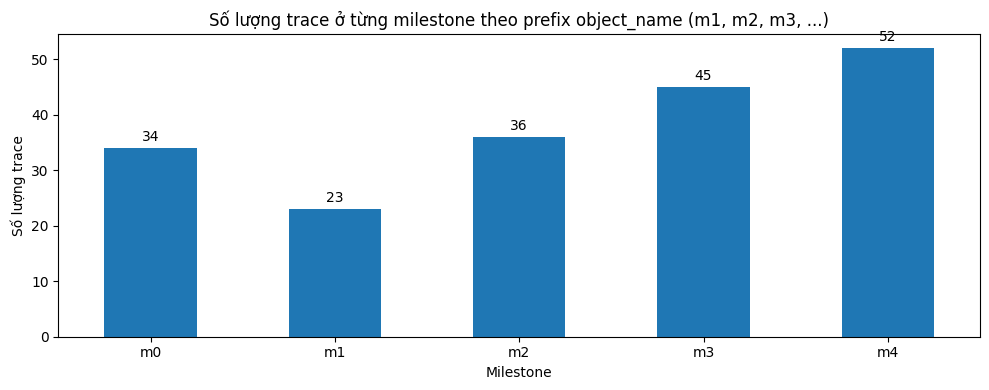

## Bảng top traces

,trace_id,milestone_id,object_name,route_id,count
0,TRACE_ASK_PERSON,0,m0_guard,CH1_M0_R0_BB_3,12
1,TRACE_ASK_PERSON,0,m0_linh_askgroup,CH1_M0_R0_BB_4,11
25,TRACE_READ_RELEVANT_INFO,0,m0_email_checkin,CH1_M0_R0_BB_1,11
40,TRACE_WARN_OTHERS,3,m3_classgroup,CH1_M3_R0_BB_2,10
8,TRACE_ASK_PERSON,3,m4_email_scholarship_askroomate,CH1_M3_R0_BB_5,9
41,TRACE_WARN_OTHERS,4,m4_classgroup,CH1_M4_R0_BB_0,9
20,TRACE_INSPECT_SOURCE,4,m4_email_scholarship,CH1_M4_R3_BB_1,9
2,TRACE_ASK_PERSON,0,m1_roommate_askdoc,CH1_M0_R0_BB_13,8
30,TRACE_REFUSE_RISKY_REQUEST,4,m4_email_scholarship,CH1_M4_R3_BB_2,8
5,TRACE_ASK_PERSON,3,m3_namchat_Mai,CH1_M3_R2_BB_1,7


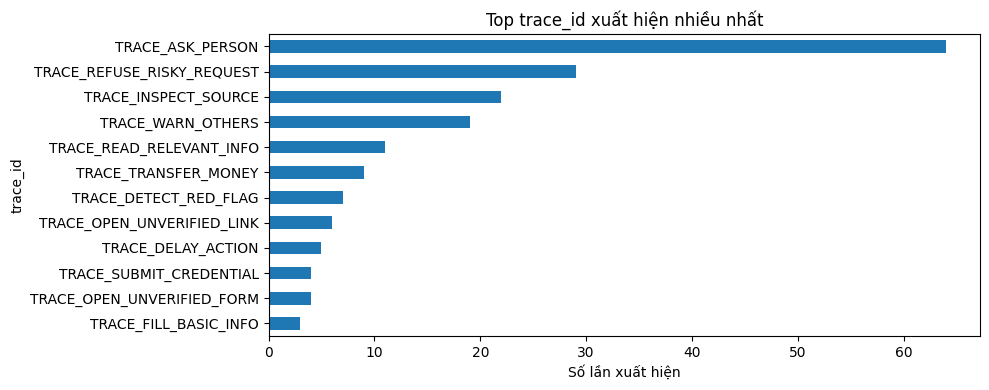

## Phân loại trace safe và risky

trace_category
safe     157
risky     33
Name: count, dtype: int64

## Phân loại trace theo trace_id

,trace_category,trace_id,count
0,risky,TRACE_FILL_BASIC_INFO,3
1,risky,TRACE_FILL_SENSITIVE_INFO,3
2,risky,TRACE_IGNORE_RED_FLAG,2
3,risky,TRACE_OPEN_UNVERIFIED_FORM,4
4,risky,TRACE_OPEN_UNVERIFIED_LINK,6
5,risky,TRACE_SUBMIT_AUTH_CODE,2
6,risky,TRACE_SUBMIT_CREDENTIAL,4
7,risky,TRACE_TRANSFER_MONEY,9
8,safe,TRACE_ASK_PERSON,64
9,safe,TRACE_DELAY_ACTION,5


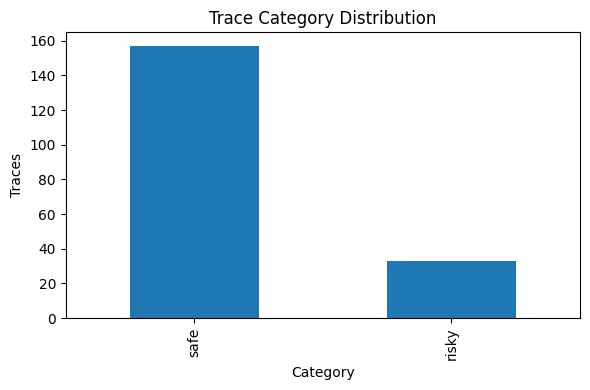

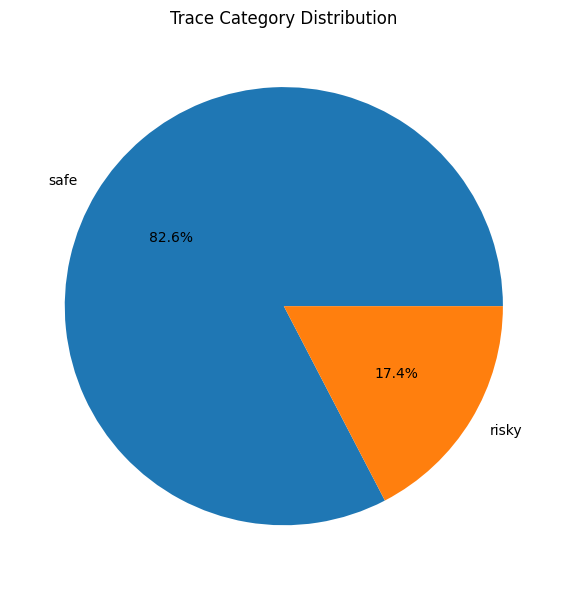

## Số trace safe và risky ở từng milestone

trace_category,risky,safe
milestone_prefix,,
m0,0.0,34.0
m1,9.0,14.0
m2,9.0,27.0
m3,1.0,44.0
m4,14.0,38.0


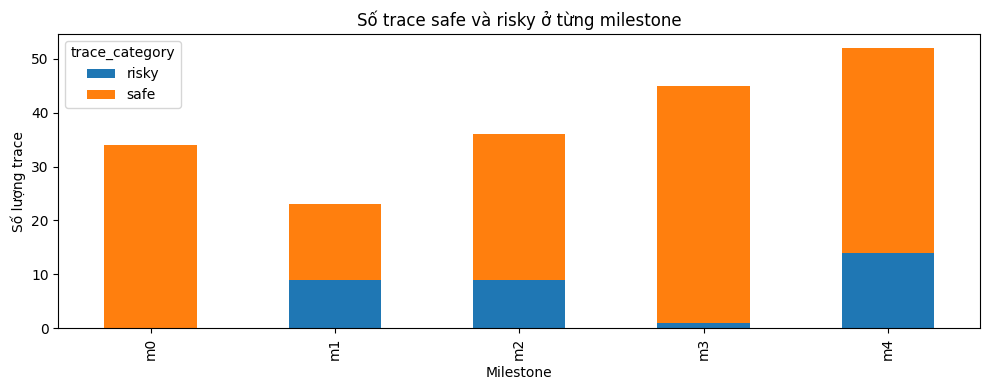

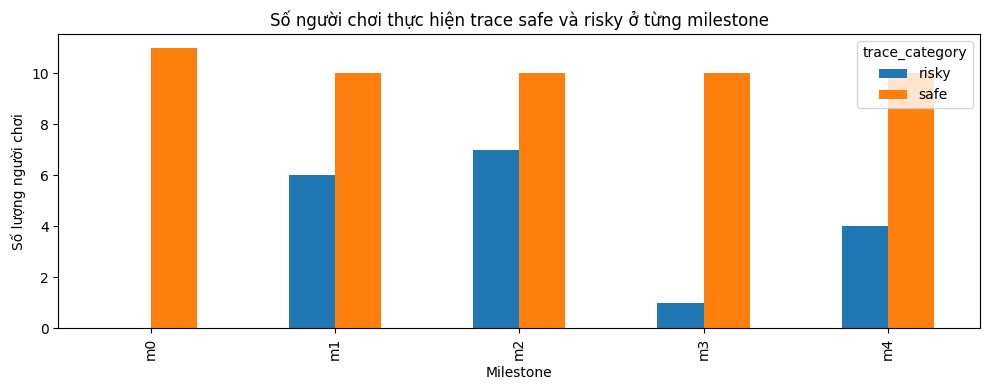

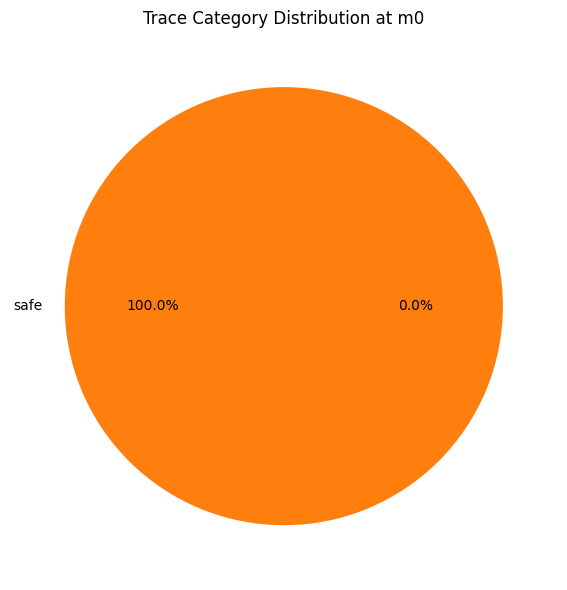

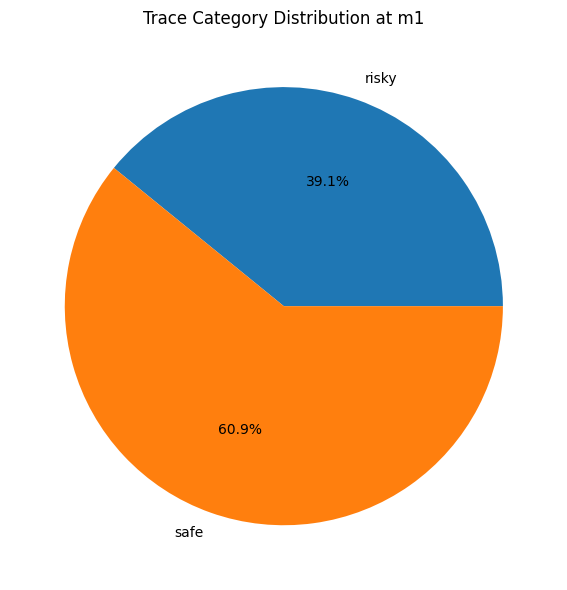

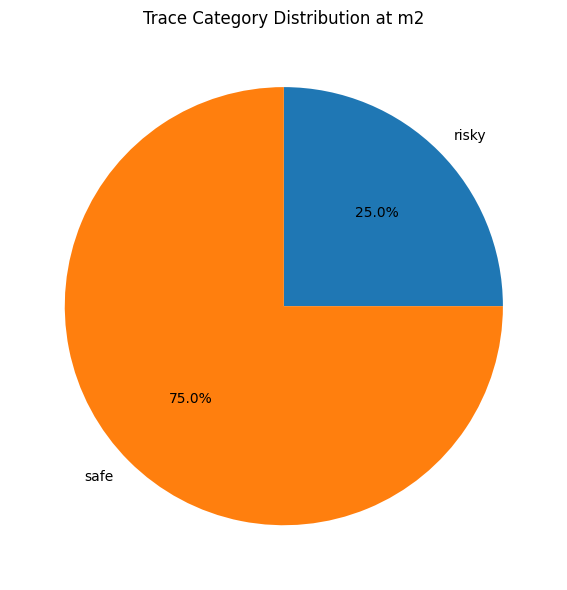

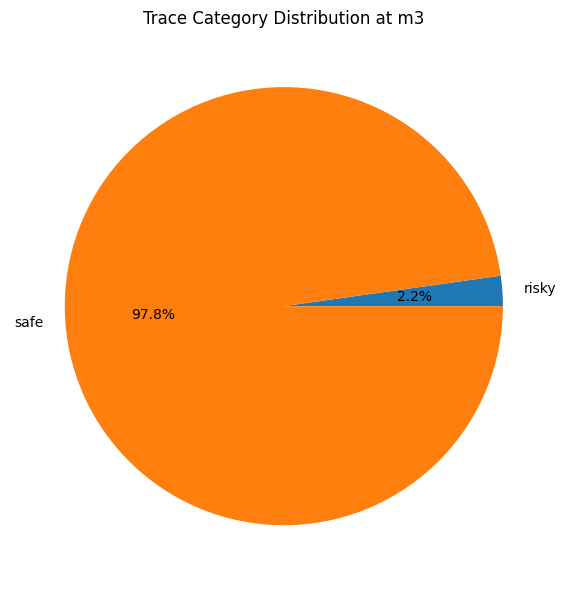

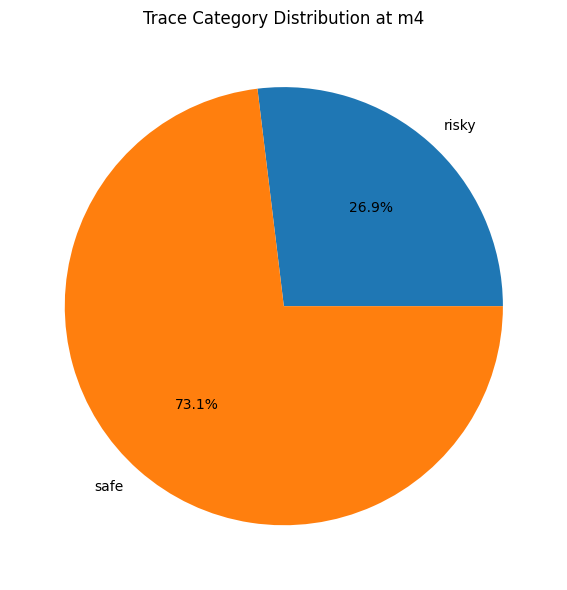

,milestone_prefix,tricked_count
0,m0,0
1,m1,2
2,m2,8
3,m3,1
4,m4,4


,milestone,total_players,safe_players,risky_players,tricked_players
0,m1,11,10,6,2
1,m2,11,10,7,7
2,m3,11,10,1,1
3,m4,11,10,4,2


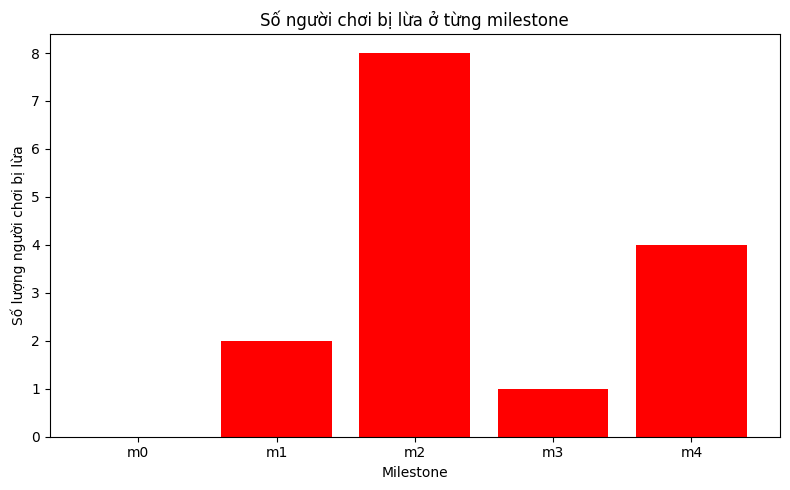

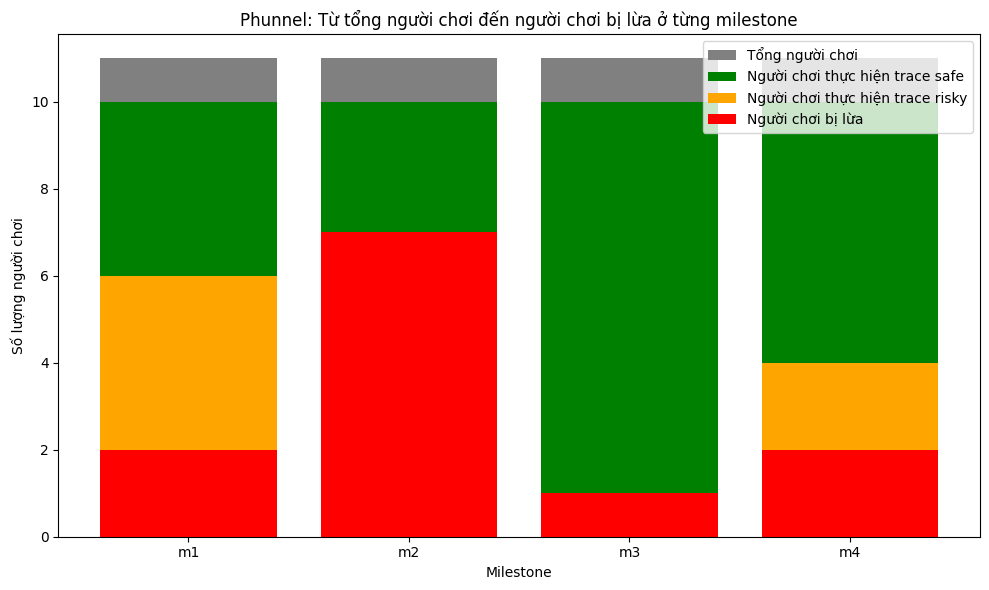

In [108]:

from IPython.display import display, Markdown
#  Trace / hành vi trong game
display(Markdown("## Phân bố trace, các loại trace"))
trace_counts = traces_df["trace_id"].value_counts().sort_values(ascending=False)
display(trace_counts.to_frame("count"))
print("Tổng số trace đã thu được:", len(traces_df))

# # Số lượng trace thu được ở từng milestone và biểu đồ cột đứng theo milstone_id sort theo thứ tự milestone
# milestone_counts = traces_df["milestone_id"].value_counts().sort_index()
# display(milestone_counts.to_frame("count"))
# #biểu đồ cột
# fig, ax = plt.subplots()
# milestone_counts.sort_index().plot(kind="bar", ax=ax)
# ax.set_title("Số lượng trace ở từng Milestone")
# ax.set_xlabel("milestone_id")
# ax.set_ylabel("Số lượng trace")
# plt.tight_layout()

# Tổng Số lượng trace thu được ở từng milestone tgiống như ở trên nhưng khác là ở đây ính theo object_name, sort theo object name như m1, m2, m3, không tính theo milstone_id kiểu có bao nhiêu trace có object name bắt đầu là m1,m2,m3, làm bảng và biểu đồ cột kiểu 1 trục là các mốc m1,m2,m3,.. trục còn lại là số lượng trace có object_name bắt đầu bằng m1,m2,m3
display(Markdown("## Số lượng trace thu được ở từng milestone"))
traces_df["milestone_prefix"] = traces_df["object_name"].str.extract(r"^(m\d+)", expand=False)
milestone_prefix_counts = traces_df["milestone_prefix"].value_counts().sort_index()
display(milestone_prefix_counts.to_frame("count"))
#biểu đồ cột
fig, ax = plt.subplots()

milestone_prefix_counts.sort_index().plot(kind="bar", ax=ax, rot=0)
ax.bar_label(ax.containers[0], padding=3)
ax.set_title("Số lượng trace ở từng milestone theo prefix object_name (m1, m2, m3, ...)")
ax.set_xlabel("Milestone")
ax.set_ylabel("Số lượng trace")
plt.tight_layout()
plt.show()


# Bảng top số trace thu được nhiều nhất theo trace_id, milestone_id, object_name,route_id
display(Markdown("## Bảng top traces"))
top_traces = traces_df.groupby(["trace_id", "milestone_id", "object_name", "route_id"]).size().reset_index(name="count").sort_values("count", ascending=False)
display(top_traces)

fig, ax = plt.subplots()
trace_counts.head(12).sort_values().plot(kind="barh", ax=ax)
ax.set_title("Top trace_id xuất hiện nhiều nhất")
ax.set_xlabel("Số lần xuất hiện")
plt.tight_layout()
plt.show()

# Phân loại trace_id thành 3 nhóm: safe, risky, neutral dựa trên việc có chứa các từ khóa nào trong 
display(Markdown("## Phân loại trace safe và risky"))
# print("Phân loại trace safe và risky:")
def classify_trace(trace_id):
    if not isinstance(trace_id, str):
        return "unknown"
    tid = trace_id.upper()
    safe_keys = ["REFUSE", "DETECT", "INSPECT", "VERIFY", "WARN", "ASK_PERSON", "DELAY", "READ_RELEVANT_INFO"]
    risky_keys = ["TRANSFER", "OPEN_UNVERIFIED", "IGNORE", "SUBMIT", "FILL"]
    if any(k in tid for k in safe_keys):
        return "safe"
    if any(k in tid for k in risky_keys):
        return "risky"
    return "neutral"

if not traces_df.empty:
    traces_df["trace_category"] = traces_df["trace_id"].apply(classify_trace)
    category_counts = traces_df["trace_category"].value_counts()
    display(category_counts)

    #Bảng phân loại từng loại trace thu dược là safe hay 
    display(Markdown("## Phân loại trace theo trace_id"))
    category_trace_counts = traces_df.groupby(["trace_category", "trace_id"]).size().reset_index(name="count")
    display(category_trace_counts)

    plt.figure(figsize=(6, 4))
    category_counts.plot(kind="bar")
    plt.title("Trace Category Distribution")
    plt.xlabel("Category")
    plt.ylabel("Traces")
    plt.tight_layout()
    plt.show()
    # pie chart
    plt.figure(figsize=(6, 6))
    category_counts.plot(kind="pie", autopct="%1.1f%%")
    plt.title("Trace Category Distribution")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

    #Bảng số trace safe và risky ở từng milstone theo object name, kiểu có bao nhiêu trace safe, risky ở từng milestone m1,m2,m3,... dựa trên prefix object_name, làm bảng và biểu đồ cột kiểu 1 trục là các mốc m1,m2,m3,.. trục còn lại là số lượng trace safe, risky ở từng milestone đó
    display(Markdown("## Số trace safe và risky ở từng milestone"))
    milestone_category_counts = traces_df.groupby(["milestone_prefix", "trace_category"]).size().reset_index(name="count")
    milestone_category_pivot = milestone_category_counts.pivot(index="milestone_prefix", columns="trace_category", values="count").fillna(0)
    display(milestone_category_pivot)
    #biểu đồ cột cho safe và risky ở từng milestone
    milestone_category_pivot.plot(kind="bar", stacked=True)
    plt.title("Số trace safe và risky ở từng milestone")
    plt.xlabel("Milestone")
    plt.ylabel("Số lượng trace")
    plt.tight_layout()
    #Biểu đồ cột đôi cho số lượng người chơi thực hiện safe,risky ở từng milestone, kiểu 1 trục là các mốc m1,m2,m3,.. trục còn lại là số lượng người chơi thực hiện trace safe, risky ở từng milestone đó, dựa trên prefix object_name,2 cột đứng cạnh nhau, 1 cột là số lượng người chơi safe, 1 cột là số lượng người chơi risky ở từng milestone
    milestone_player_category_pivot = milestone_player_category_counts.pivot(index="milestone_prefix", columns="trace_category", values="player_count").fillna(0)
    milestone_player_category_pivot.plot(kind="bar")
    plt.title("Số người chơi thực hiện trace safe và risky ở từng milestone")
    plt.xlabel("Milestone")
    plt.ylabel("Số lượng người chơi")
    plt.tight_layout()
    plt.show()
    #pie chart cho từng milestone
    for milestone in milestone_category_pivot.index:
        plt.figure(figsize=(6, 6))
        milestone_category_pivot.loc[milestone].plot(kind="pie", autopct="%1.1f%%")
        plt.title(f"Trace Category Distribution at {milestone}")
        plt.ylabel("")
        plt.tight_layout()

        plt.show()

        # m1: TRACE_SUBMIT_CREDENTIAL, m2: TRACE_TRANSFER_MONEY, m3: TRACE_TRANSFER_MONEY, m4: TRACE_SUBMIT_CREDENTIAL, TRACE_SUBMIT_AUTH_CODE đây là các trace nếu xuất hiện ở đúng các mốc đó thì đc xem là người chơi đã bị lừa, bây giờ thống kê có bao nhiêu người chơi đã bị lừa ở mỗi milestone, kiểu nếu có trace_id nào chứa các từ khóa trên ở đúng milestone đó thì tính là người chơi đó bị lừa, làm bảng và biểu đồ cột kiểu 1 trục là các mốc m1,m2,m3,.. trục còn lại là số lượng người chơi bị lừa ở từng milestone đó, dựa trên prefix object_name, lưu ý 1 người chơi có thể có nhiều session, tính số lượng player chứ ko phải
    def is_tricked(row):
        tid = str(row["trace_id"]).upper()
        mp = row["milestone_prefix"]
        if mp == "m1" and "TRACE_SUBMIT_CREDENTIAL" in tid:
            return True
        if mp == "m2" and "TRACE_TRANSFER_MONEY" in tid:
            return True
        if mp == "m3" and "TRACE_TRANSFER_MONEY" in tid:
            return True
        if mp == "m4" and any(k in tid for k in ["TRACE_SUBMIT_CREDENTIAL", "TRACE_SUBMIT_AUTH_CODE"]):
            return True
        return False
    traces_df["is_tricked"] = traces_df.apply(is_tricked, axis=1)
    tricked_counts = traces_df.groupby("milestone_prefix")["is_tricked"].sum().reset_index(name="tricked_count")
    display(tricked_counts)
    # biểu đồ cột cho số lượng người chơi bị lừa ở từng milestone
    plt.figure(figsize=(8, 5))
    plt.bar(tricked_counts["milestone_prefix"], tricked_counts["tricked_count"], color="red")
    plt.title("Số người chơi bị lừa ở từng milestone")
    plt.xlabel("Milestone")
    plt.ylabel("Số lượng người chơi bị lừa")
    plt.tight_layout()

    #làm phunnel để thể hiện người chơi dù thực hiện safe trace xong cuối cùng vẫn bị lừa và người chơi ko thực hiện safe trace, chỉ toàn là risky trace và cuối cùng bị lừa
    funnel_data = []
    for milestone in ["m1", "m2", "m3", "m4"]:
        milestone_traces = traces_df[traces_df["milestone_prefix"] == milestone]
        total_players = milestone_traces["player_id"].nunique()
        safe_players = milestone_traces[milestone_traces["trace_category"] == "safe"]["player_id"].nunique()
        risky_players = milestone_traces[milestone_traces["trace_category"] == "risky"]["player_id"].nunique()
        tricked_players = milestone_traces[milestone_traces["is_tricked"]]["player_id"].nunique()
        funnel_data.append({
            "milestone": milestone,
            "total_players": total_players,
            "safe_players": safe_players,
            "risky_players": risky_players,
            "tricked_players": tricked_players
        })
    funnel_df = pd.DataFrame(funnel_data)
    display(funnel_df)
    # biểu đồ phunnel
    plt.figure(figsize=(10, 6))
    plt.bar(funnel_df["milestone"], funnel_df["total_players"], color="gray", label="Tổng người chơi")
    plt.bar(funnel_df["milestone"], funnel_df["safe_players"], color="green", label="Người chơi thực hiện trace safe")
    plt.bar(funnel_df["milestone"], funnel_df["risky_players"], color="orange", label="Người chơi thực hiện trace risky")
    plt.bar(funnel_df["milestone"], funnel_df["tricked_players"], color="red", label="Người chơi bị lừa")
    plt.title("Phunnel: Từ tổng người chơi đến người chơi bị lừa ở từng milestone")
    plt.xlabel("Milestone")
    plt.ylabel("Số lượng người chơi")
    plt.legend()
    plt.tight_layout()
    


### 3. Phân tích Biểu đồ Kỹ năng (Skill Radar Analysis)

Đánh giá 5 chỉ số điểm kết thúc (final scores) thông qua Biểu đồ mạng nhện. Thông qua đó cho thấy điểm mạnh và điểm yếu nhất của người chơi khi đối mặt với rủi ro mạng.

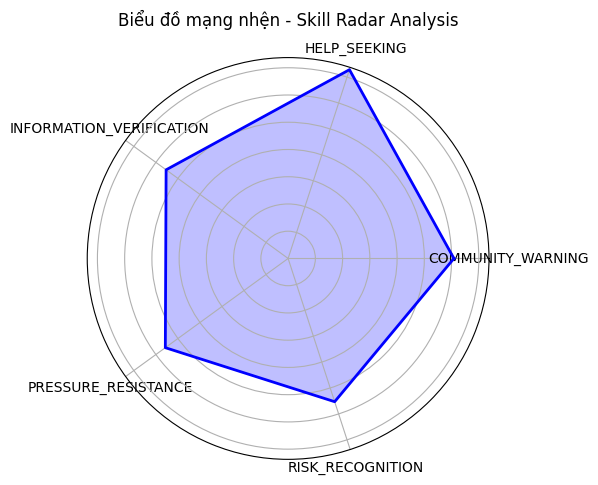

,mean_final_score
SCORE_COMMUNITY_WARNING,60.86
SCORE_HELP_SEEKING,72.86
SCORE_INFORMATION_VERIFICATION,55.36
SCORE_PRESSURE_RESISTANCE,55.71
SCORE_RISK_RECOGNITION,55.29


In [17]:
# 2. Phân tích Biểu đồ Kỹ năng (Skill Radar Analysis)
score_cols = [c for c in sessions_df.columns if c.startswith("SCORE_")]
score_means = sessions_df[score_cols].mean()

# Chuẩn bị dữ liệu vẽ Radar
labels = [c.replace("SCORE_", "") for c in score_means.index]
stats = score_means.values

angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
stats = np.concatenate((stats, [stats[0]]))
angles += [angles[0]]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
ax.fill(angles, stats, color='blue', alpha=0.25)
ax.plot(angles, stats, color='blue', linewidth=2)
ax.set_yticklabels([])
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=10)
ax.set_title("Biểu đồ mạng nhện - Skill Radar Analysis", va='bottom', pad=20)
plt.tight_layout()
plt.show()

display(score_means.to_frame("mean_final_score").round(2))

### 4. Điểm đánh giá trung bình qua các Milestone

In [18]:
import pandas as pd

# 1. Lọc ra danh sách tất cả các cột điểm (bắt đầu bằng SCORE_) trong traces_df
score_cols = [c for c in traces_df.columns if c.startswith("SCORE_")]

# 2. Tính điểm trung bình của tất cả các hệ chỉ số theo từng milestone
milestone_mean_wide = traces_df.groupby("milestone_id")[score_cols].mean().reset_index()

# 3. Chuyển bảng từ dạng ngang (wide) sang dạng dọc (long) 
# để tạo ra cột 'score_name' và 'score_value' dùng cho việc vẽ biểu đồ
milestone_mean = milestone_mean_wide.melt(
    id_vars=["milestone_id"], 
    value_vars=score_cols, 
    var_name="score_name", 
    value_name="score_value"
)

# Xem thử để kiểm tra xem đã có cột score_name và score_value chưa
display(milestone_mean)

,milestone_id,score_name,score_value
0,0,SCORE_COMMUNITY_WARNING,50.000000
1,1,SCORE_COMMUNITY_WARNING,50.000000
2,2,SCORE_COMMUNITY_WARNING,50.000000
3,3,SCORE_COMMUNITY_WARNING,51.777778
4,4,SCORE_COMMUNITY_WARNING,56.800000
5,0,SCORE_HELP_SEEKING,53.695652
6,1,SCORE_HELP_SEEKING,63.260870
7,2,SCORE_HELP_SEEKING,66.388889
8,3,SCORE_HELP_SEEKING,71.777778
9,4,SCORE_HELP_SEEKING,74.625000


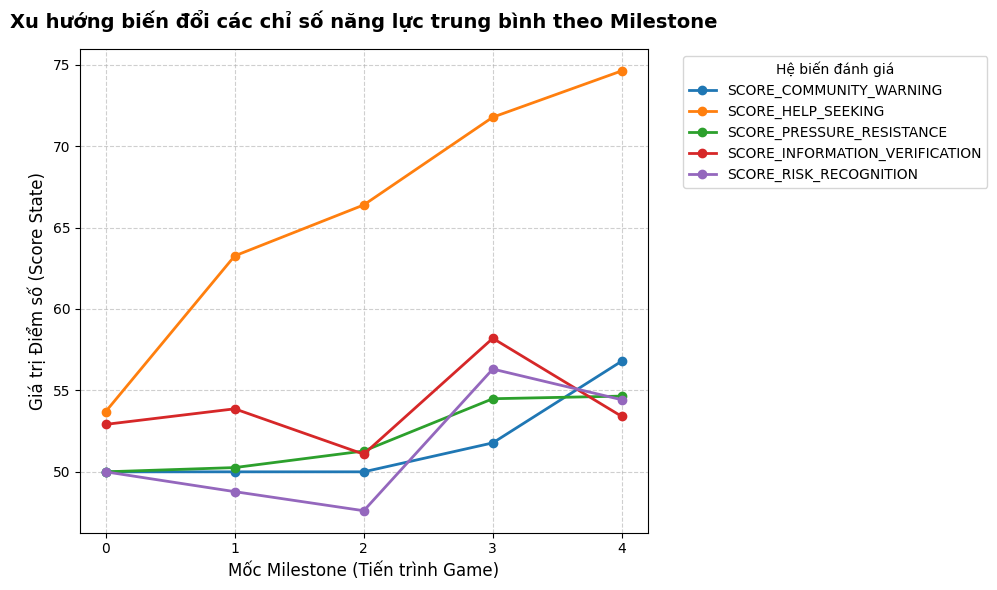

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Chuyển đổi cột milestone_id sang kiểu số để sắp xếp chính xác theo tuyến tính
milestone_mean["milestone_id"] = pd.to_numeric(
    milestone_mean["milestone_id"], errors="coerce"
)
milestone_mean = milestone_mean.dropna(subset=["milestone_id"]).sort_values(
    "milestone_id"
)

# 2. Khởi tạo biểu đồ
fig, ax = plt.subplots(figsize=(10, 6))

# 3. Lọc và vẽ từng chỉ số (5 chỉ số SCORE) lên cùng một ax
unique_scores = milestone_mean["score_name"].unique()

for score in unique_scores:
    score_data = milestone_mean[milestone_mean["score_name"] == score]
    ax.plot(
        score_data["milestone_id"],
        score_data["score_value"],
        marker="o",
        linewidth=2,
        label=score,  # Gán nhãn để hiển thị ở Chú thích (Legend)
    )

# 4. Định dạng biểu đồ đạt chuẩn báo cáo học thuật
ax.set_title(
    "Xu hướng biến đổi các chỉ số năng lực trung bình của 11 player theo Milestone",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
ax.set_xlabel("Mốc Milestone (Tiến trình Game)", fontsize=12)
ax.set_ylabel("Giá trị Điểm số (Score State)", fontsize=12)

# Đảm bảo trục X hiển thị dạng số nguyên của Milestone, không bị chia nhỏ thành số thập phân
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

# Thêm lưới grid mờ để dễ quan sát tiến trình
ax.grid(True, linestyle="--", alpha=0.6)

# Hiển thị bảng chú thích ở vị trí tối ưu (không đè lên đường vẽ)
ax.legend(title="Hệ biến đánh giá", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.savefig("xu_huong_5_metrics_milestone.png", dpi=300)
plt.show()




## 7. Khảo sát

Phần này đọc Form1, Form2 và tab Phổ điểm.

- Form1: trước khi chơi
- Form2: sau khi chơi / có thêm thông tin người trả lời
- Phổ điểm: danh sách participant experiment và các bảng đã dựng sẵn

Notebook sẽ tự tính:
- `Score` tổng
- `K_mean`, `A_mean`
- `G_mean` cho Form2
- ghép `pre` / `post` theo email


In [88]:

survey_xl = pd.ExcelFile(SURVEY_PATH)
print(survey_xl.sheet_names)

form1 = pd.read_excel(SURVEY_PATH, sheet_name="Form1")
form2 = pd.read_excel(SURVEY_PATH, sheet_name="Form2")
pho_diem = pd.read_excel(SURVEY_PATH, sheet_name="Phổ điểm")

def norm_email(series):
    return series.astype(str).str.strip().str.lower()

form1["email_norm"] = norm_email(form1["Email Address"])
form2["email_norm"] = norm_email(form2["Email Address"])
pho_diem["email_norm"] = norm_email(pho_diem["Email"])
# 1. Chuẩn hóa cột Email trong tab phổ điểm để merge chính xác
pho_diem["email_norm"] = norm_email(pho_diem["Email"])

# Tạo một bảng mapping gọn gàng gồm 3 cột cần thiết từ pho_diem
player_mapping = pho_diem[["email_norm", "Player email", "UID"]].drop_duplicates()

# 2. Merge thông tin Player email và UID vào form1
form1 = form1.merge(player_mapping, on="email_norm", how="left")

# 3. Merge thông tin Player email và UID vào form2
form2 = form2.merge(player_mapping, on="email_norm", how="left")

df_player_info = pho_diem[["UID", "Player email", "Email"]].drop_duplicates()

def cols_by_prefix(df, prefix):
    return [c for c in df.columns if isinstance(c, str) and c.startswith(prefix)]

form1_k_cols = cols_by_prefix(form1, "K")
form1_a_cols = cols_by_prefix(form1, "A")

form2_k_cols = cols_by_prefix(form2, "K")
form2_a_cols = cols_by_prefix(form2, "A")
form2_g_cols = cols_by_prefix(form2, "G")
form2_g_num_cols = [c for c in form2_g_cols if re.match(r"^G\d+\.", c)]

for df in [form1, form2]:
    if "Score" in df.columns:
        df["Score"] = pd.to_numeric(df["Score"], errors="coerce")

form1["K_mean"] = form1[form1_k_cols].apply(pd.to_numeric, errors="coerce").mean(axis=1)
form1["A_mean"] = form1[form1_a_cols].apply(pd.to_numeric, errors="coerce").mean(axis=1)

form2["K_mean"] = form2[form2_k_cols].apply(pd.to_numeric, errors="coerce").mean(axis=1)
form2["A_mean"] = form2[form2_a_cols].apply(pd.to_numeric, errors="coerce").mean(axis=1)
form2["G_mean"] = form2[form2_g_num_cols].apply(pd.to_numeric, errors="coerce").mean(axis=1)

# display(form1[["Email Address", "Score", "K_mean", "A_mean"]])
# display(form2[["Email Address", "Score", "K_mean", "A_mean", "G_mean"]])
# display(pho_diem)

# --- ĐOẠN NÀY ĐỂ BẠN KIỂM TRA LẠI OUTPUT MỚI ---
display(Markdown("### Kèm thông tin Player định danh cho Form 1"))
display(form1[["UID", "Player email", "Score", "K_mean", "A_mean"]])

display(Markdown("### Kèm thông tin Player định danh cho Form 2"))
display(form2[["UID", "Player email", "Score", "K_mean", "A_mean", "G_mean"]])

display(Markdown("### 📋 Danh sách định danh người chơi (Player Mapping)"))
display(df_player_info)


['Form1', 'Form2', 'Phổ điểm']


### Kèm thông tin Player định danh cho Form 1

,UID,Player email,Score,K_mean,A_mean
0,NaN,NaN,90,4.0,3.714286
1,Phcnngo3Fddhr78h6wLbEE8qeW22,player3@gmail.com,90,5.0,4.285714
2,EOOUznHcdYM3B5Eu7H7303gt3Nl1,player5@gmail.com,75,5.0,4.000000
3,cx0jXpRTPFb30Gsm6QOvt3Hh6KJ3,player4@gmail.com,60,2.0,2.571429
4,dhiHXvJmYgaNYeeE3QVoo77dMwf1,player6@gmail.com,105,4.2,4.285714
5,aUwWXivyj0VBPP4fmL3STw6ydC83,player7@gmail.com,120,4.6,4.000000
6,vroJdrAh69TH16ZpHxlCqeIplRw1,player8@gmail.com,105,3.6,4.857143
7,40f1uksF5kYFvJ5WxoYBzlBCfBE2,player10@gmail.com,90,4.0,3.000000
8,vYmu30ZTOHbjiC4mPuaw73q6pZf1,player9@gmail.com,90,4.4,3.571429
9,VYZqyGu79USyXvpxpxWmk0lxnAE3,player11@gmail.com,60,4.6,4.428571


### Kèm thông tin Player định danh cho Form 2

,UID,Player email,Score,K_mean,A_mean,G_mean
0,Phcnngo3Fddhr78h6wLbEE8qeW22,player3@gmail.com,120,5.0,5.000000,2.6
1,NaN,NaN,110,4.4,3.714286,4.0
2,EOOUznHcdYM3B5Eu7H7303gt3Nl1,player5@gmail.com,100,4.4,4.285714,3.7
3,NaN,NaN,80,3.4,4.857143,4.0
4,cx0jXpRTPFb30Gsm6QOvt3Hh6KJ3,player4@gmail.com,100,4.4,4.000000,4.9
5,dhiHXvJmYgaNYeeE3QVoo77dMwf1,player6@gmail.com,110,5.0,4.142857,2.6
6,vroJdrAh69TH16ZpHxlCqeIplRw1,player8@gmail.com,120,4.4,4.285714,4.4
7,40f1uksF5kYFvJ5WxoYBzlBCfBE2,player10@gmail.com,110,4.2,3.428571,4.8
8,vYmu30ZTOHbjiC4mPuaw73q6pZf1,player9@gmail.com,120,4.4,3.714286,4.8
9,VYZqyGu79USyXvpxpxWmk0lxnAE3,player11@gmail.com,110,5.0,5.000000,4.5


### 📋 Danh sách định danh người chơi (Player Mapping)

,UID,Player email,Email
0,Phcnngo3Fddhr78h6wLbEE8qeW22,player3@gmail.com,trungdo2306@gmail.com
1,EOOUznHcdYM3B5Eu7H7303gt3Nl1,player5@gmail.com,nguyenlanhuong15679@gmail.com
2,cx0jXpRTPFb30Gsm6QOvt3Hh6KJ3,player4@gmail.com,ngnghia021204@gmail.com
3,dhiHXvJmYgaNYeeE3QVoo77dMwf1,player6@gmail.com,teomachine0@gmail.com
4,aUwWXivyj0VBPP4fmL3STw6ydC83,player7@gmail.com,1846colh1093@gmail.com
5,vroJdrAh69TH16ZpHxlCqeIplRw1,player8@gmail.com,phantrungducnguyen@gmail.com
6,40f1uksF5kYFvJ5WxoYBzlBCfBE2,player10@gmail.com,nguyencongloiero112233@gmail.com
7,vYmu30ZTOHbjiC4mPuaw73q6pZf1,player9@gmail.com,truongchiminh2k4@gmail.com
8,VYZqyGu79USyXvpxpxWmk0lxnAE3,player11@gmail.com,akhaclinh123@gmail.com
9,1gJPPFrwADbPzDMNxwIhKHuCPWv1,player12@gmail.com,phuclion2013@gmail.com


### 📊 Bảng so sánh Pre/Post theo Player

,Player email_pre,Score_pre,Score_post,delta_score,K_mean_pre,K_mean_post
8,player11@gmail.com,60,110,50,4.6,5.0
2,player4@gmail.com,60,100,40,2.0,4.4
9,player12@gmail.com,45,80,35,4.6,4.2
7,player9@gmail.com,90,120,30,4.4,4.4
0,player3@gmail.com,90,120,30,5.0,5.0
1,player5@gmail.com,75,100,25,5.0,4.4
6,player10@gmail.com,90,110,20,4.0,4.2
5,player8@gmail.com,105,120,15,3.6,4.4
3,player6@gmail.com,105,110,5,4.2,5.0
4,player7@gmail.com,120,120,0,4.6,4.2


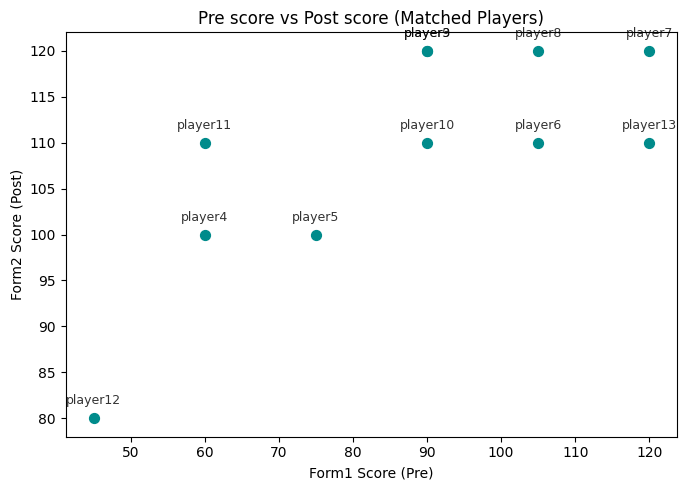

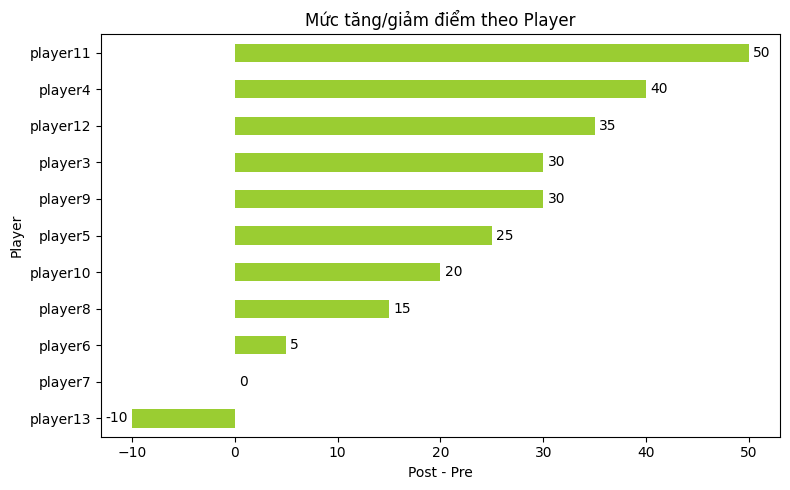

In [89]:

# 1. Thêm "Player email" vào danh sách cột khi merge
pre_post = (
    form1[["email_norm", "Player email", "Score", "K_mean", "A_mean"]]
    .merge(
        form2[["email_norm", "Player email", "Score", "K_mean", "A_mean", "G_mean"]],
        on="email_norm",
        how="inner",
        suffixes=("_pre", "_post")
    )
)

pre_post["delta_score"] = pre_post["Score_post"] - pre_post["Score_pre"]

# Tạo thêm 1 cột tên ngắn (ví dụ: player3) để đưa lên biểu đồ cho đẹp, không bị dài
pre_post["player_short"] = pre_post["Player email_pre"].str.split("@").str[0]

# Hiển thị bảng theo thứ tự giảm dần của delta_score
display(Markdown("### 📊 Bảng so sánh Pre/Post theo Player"))
display(pre_post[["Player email_pre", "Score_pre", "Score_post", "delta_score", "K_mean_pre", "K_mean_post"]].sort_values("delta_score", ascending=False))

# --- BIỂU ĐỒ SCATTER PLOT ---
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(pre_post["Score_pre"], pre_post["Score_post"], color="darkcyan", s=50)

# SỬA Ở ĐÂY: Hiện chữ dạng player3, player4... lên chấm điểm
for _, r in pre_post.iterrows():
    # Sử dụng cột player_short vừa tạo
    ax.annotate(r["player_short"], (r["Score_pre"], r["Score_post"]), 
                textcoords="offset points", xytext=(0,10), ha='center', fontsize=9, alpha=0.8)

ax.set_title("Pre score vs Post score (Matched Players)")
ax.set_xlabel("Form1 Score (Pre)")
ax.set_ylabel("Form2 Score (Post)")
plt.tight_layout()
plt.show()

# --- BIỂU ĐỒ CỘT NGANG ---
fig, ax = plt.subplots(figsize=(8, 5))

# Sắp xếp lại dữ liệu theo delta_score trước khi vẽ
pre_post_sorted = pre_post.sort_values("delta_score")

# Vẽ cột ngang
pre_post_sorted["delta_score"].plot(kind="barh", ax=ax, color="yellowgreen")

# SỬA Ở ĐÂY: Ép trục Y hiển thị tên player ngắn (player3, player4...) thay vì số index
ax.set_yticks(range(len(pre_post_sorted)))
ax.set_yticklabels(pre_post_sorted["player_short"])

# Hiện luôn số tăng giảm ở đầu cột cho dễ nhìn như bài trước làm nè
ax.bar_label(ax.containers[0], padding=3)

ax.set_title("Mức tăng/giảm điểm theo Player")
ax.set_xlabel("Post - Pre")
ax.set_ylabel("Player")
plt.tight_layout()
plt.show()


,player_id,session_count,completed_count,completion_rate,mean_playtime,median_playtime,mean_final_score,best_final_score,worst_final_score,trace_count,player_email,email_norm,Score,G_mean,K_mean,A_mean,"Truớc khi thực hiện khảo sát, bạn đã có trải nghiệm và hoàn thành game chưa?"


,mean_final_score,best_final_score,mean_playtime,trace_count,Score,G_mean
mean_final_score,NaN,NaN,NaN,NaN,NaN,NaN
best_final_score,NaN,NaN,NaN,NaN,NaN,NaN
mean_playtime,NaN,NaN,NaN,NaN,NaN,NaN
trace_count,NaN,NaN,NaN,NaN,NaN,NaN
Score,NaN,NaN,NaN,NaN,NaN,NaN
G_mean,NaN,NaN,NaN,NaN,NaN,NaN


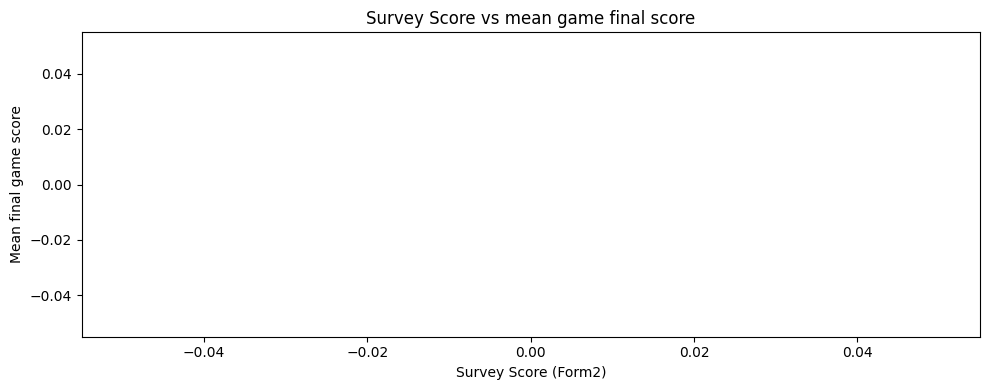

In [93]:

# Ghép game log với survey theo email
game_player_email = players_df[["player_id", "email"]].rename(columns={"email": "player_email"})
game_player_email["email_norm"] = norm_email(game_player_email["player_email"])

player_summary = (
    sessions_df.groupby("player_id")
    .agg(
        session_count=("session_id", "count"),
        completed_count=("is_completed", "sum"),
        completion_rate=("is_completed", "mean"),
        mean_playtime=("total_playtime_seconds", "mean"),
        median_playtime=("total_playtime_seconds", "median"),
        mean_final_score=("mean_final_score", "mean"),
        best_final_score=("mean_final_score", "max"),
        worst_final_score=("mean_final_score", "min"),
        trace_count=("n_traces", "sum"),
    )
    .reset_index()
)

player_summary = player_summary.merge(game_player_email, on="player_id", how="left")

survey_game = (
    player_summary
    .merge(
        form2[["email_norm", "Score", "G_mean", "K_mean", "A_mean", "Truớc khi thực hiện khảo sát, bạn đã có trải nghiệm và hoàn thành game chưa?"]],
        on="email_norm",
        how="inner"
    )
)

display(survey_game.head())

corr_cols = ["mean_final_score", "best_final_score", "mean_playtime", "trace_count", "Score", "G_mean"]
display(survey_game[corr_cols].corr(numeric_only=True).round(3))

fig, ax = plt.subplots()
ax.scatter(survey_game["Score"], survey_game["mean_final_score"])
ax.set_title("Survey Score vs mean game final score")
ax.set_xlabel("Survey Score (Form2)")
ax.set_ylabel("Mean final game score")
plt.tight_layout()
plt.show()


### Phân bố pre test và nhóm chưa chơi

In [25]:

# Chọn mẫu control matched theo phân bố điểm pre-test
wb = openpyxl.load_workbook(SURVEY_PATH, data_only=True)
ws = wb["Phổ điểm"]

experiment_emails = []
for r in range(2, 13):  # C2:C12
    val = ws[f"C{r}"].value
    if val:
        experiment_emails.append(str(val).strip().lower())

experiment_emails = sorted(set(experiment_emails))
print(experiment_emails)

experiment_pre = form1[form1["email_norm"].isin(experiment_emails)].copy()
control_pool = form2[~form2["email_norm"].isin(experiment_emails)].copy()

bins = [0, 60, 90, 110, 121]
labels = ["0-59", "60-89", "90-109", "110-120"]

experiment_pre["band"] = pd.cut(experiment_pre["Score"], bins=bins, right=False, labels=labels)
control_pool["band"] = pd.cut(control_pool["Score"], bins=bins, right=False, labels=labels)

target_counts = experiment_pre["band"].value_counts().reindex(labels, fill_value=0)
pool_counts = control_pool["band"].value_counts().reindex(labels, fill_value=0)

display(pd.DataFrame({"experiment_target": target_counts, "control_pool": pool_counts}))


['1846colh1093@gmail.com', 'akhaclinh123@gmail.com', 'chiennguyentranthanh123@gmail.com', 'ngnghia021204@gmail.com', 'nguyencongloiero112233@gmail.com', 'nguyenlanhuong15679@gmail.com', 'phantrungducnguyen@gmail.com', 'phuclion2013@gmail.com', 'teomachine0@gmail.com', 'trungdo2306@gmail.com', 'truongchiminh2k4@gmail.com']


,experiment_target,control_pool
band,,
0-59,1,0
60-89,3,3
90-109,5,4
110-120,2,12


,Email Address,Score
0,trileletri39@gmail.com,80
1,Hanatang4904@gmail.com,80
2,nguyentuankiet03082004@gmail.com,80
4,chuquynh2004@gmail.com,90
3,tranuyqhc1@gmail.com,100
5,nltt2709@gmail.com,100
6,khoa.truonganh@hcmut.edu.vn,100
7,mytien1278@gmail.com,110
8,anhthu12040204@gmail.com,110


count      9.000000
mean      94.444444
std       12.360331
min       80.000000
25%       80.000000
50%      100.000000
75%      100.000000
max      110.000000
Name: Score, dtype: float64

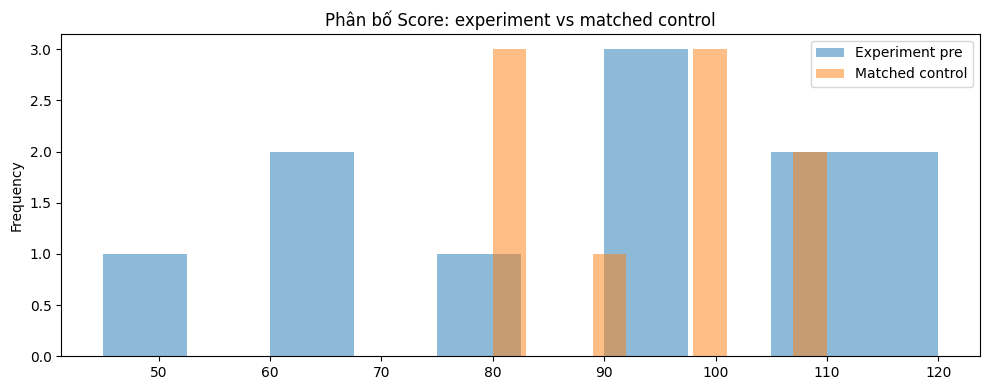

In [26]:

def stratified_sample_by_band(df_pool, target_counts, score_col="Score", bins=(0,60,90,110,121), labels=None, random_state=42):
    labels = labels or [f"{bins[i]}-{bins[i+1]-1}" for i in range(len(bins)-1)]
    df = df_pool.copy()
    df["band"] = pd.cut(df[score_col], bins=bins, right=False, labels=labels)
    sampled_parts = []
    for band, n in target_counts.items():
        if n <= 0:
            continue
        subset = df[df["band"] == band]
        if len(subset) == 0:
            continue
        take = min(int(n), len(subset))
        sampled_parts.append(subset.sample(n=take, random_state=random_state))
    sampled = pd.concat(sampled_parts, ignore_index=True) if sampled_parts else df.head(0).copy()
    return sampled.drop(columns=["band"], errors="ignore")

matched_control = stratified_sample_by_band(
    control_pool,
    target_counts=target_counts,
    score_col="Score",
    bins=bins,
    labels=labels,
    random_state=42
)

display(matched_control[["Email Address", "Score"]].sort_values("Score"))
display(matched_control["Score"].describe())

fig, ax = plt.subplots()
experiment_pre["Score"].plot(kind="hist", bins=10, alpha=0.5, ax=ax, label="Experiment pre")
matched_control["Score"].plot(kind="hist", bins=10, alpha=0.5, ax=ax, label="Matched control")
ax.legend()
ax.set_title("Phân bố Score: experiment vs matched control")
plt.tight_layout()
plt.show()



## Gợi ý đầu ra báo cáo

- Mô tả mẫu: số người, số session, completion rate, thời lượng chơi
- Hiệu quả can thiệp: pre/post score, delta, so sánh experiment vs control
- Hành vi trong game: trace_id, milestone, route, score progression
- Đối chiếu khảo sát: survey score vs game performance
- Mẫu control matched: chọn theo phân bố pre-test để tránh lệch mẫu
